In [3]:
from google.colab import files
uploaded = files.upload()

Saving archive.zip to archive.zip


In [4]:
import zipfile

with zipfile.ZipFile("archive.zip", 'r') as zip_ref:
    zip_ref.extractall("orl_faces")


import os

dataset_path = "orl_faces"
folders = os.listdir(dataset_path)

print("Number of folders:", len(folders))
print("Folders:", folders[:5])



valid_folders = [f for f in folders if f.startswith('s')]

print("Valid folders count:", len(valid_folders))





Number of folders: 41
Folders: ['s18', 's17', 's13', 's36', 's39']
Valid folders count: 40


In [6]:
import cv2
import numpy as np
import os

data = []
labels = []

dataset_path = "orl_faces"

for person in valid_folders:
    person_path = os.path.join(dataset_path, person)

    for image_name in os.listdir(person_path):
        image_path = os.path.join(person_path, image_name)

        img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
        img = cv2.resize(img, (92, 112))

        data.append(img.flatten())
        labels.append(person)

X = np.array(data)
y = np.array(labels)

print("Shape of X:", X.shape)

Shape of X: (400, 10304)


* compute mean face

In [7]:
mean_face = np.mean(X, axis=0)
print("Shape of mean face:", mean_face.shape)

Shape of mean face: (10304,)


* reshape to image

In [8]:
mean_image = mean_face.reshape(112, 92)

* Display mean face

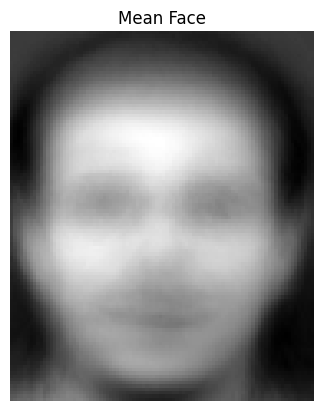

In [9]:
import matplotlib.pyplot as plt

plt.imshow(mean_image, cmap='gray')
plt.title("Mean Face")
plt.axis("off")
plt.show()

* Subtract mean

In [10]:
A = X - mean_face
print("Shape of A:", A.shape)

Shape of A: (400, 10304)


* Check one example

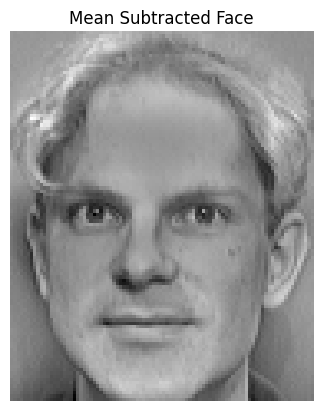

In [11]:
sample = A[0].reshape(112, 92)

plt.imshow(sample, cmap='gray')
plt.title("Mean Subtracted Face")
plt.axis("off")
plt.show()

* Compute L

In [12]:
L = np.dot(A, A.T)
print("Shape of L:", L.shape)

Shape of L: (400, 400)


* Compute Eigenvalues and Eigenvectors

In [13]:
eigenvalues, eigenvectors = np.linalg.eig(L)

print("Eigenvalues shape:", eigenvalues.shape)
print("Eigenvectors shape:", eigenvectors.shape)

Eigenvalues shape: (400,)
Eigenvectors shape: (400, 400)


* Convert to Eigenfaces

In [14]:
eigenfaces = np.dot(A.T, eigenvectors)
print("Eigenfaces shape:", eigenfaces.shape)

Eigenfaces shape: (10304, 400)


* Normalize Eigenfaces

In [15]:
for i in range(eigenfaces.shape[1]):
    eigenfaces[:, i] = eigenfaces[:, i] / np.linalg.norm(eigenfaces[:, i])

In [16]:
idx = np.argsort(-eigenvalues)   # descending order

eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]
eigenfaces = eigenfaces[:, idx]

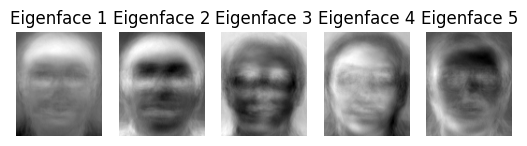

In [17]:
import matplotlib.pyplot as plt

for i in range(5):
    face = eigenfaces[:, i].reshape(112, 92)

    plt.subplot(1, 5, i+1)
    plt.imshow(face, cmap='gray')
    plt.title(f"Eigenface {i+1}")
    plt.axis('off')

plt.show()

* Select top k eigenfaces

In [18]:
k = 50   # you can try 20, 30, 50 later
U = eigenfaces[:, :k]

* Project Training Data

In [19]:
projected_train = np.dot(A, U)
print(projected_train.shape)

(400, 50)


* Test Recognition Basic and Compare with All

In [20]:
test = A[0]   # first image
test_proj = np.dot(test, U)

In [21]:
distances = np.linalg.norm(projected_train - test_proj, axis=1)
predicted_index = np.argmin(distances)

print("Predicted index:", predicted_index)
print("Actual index:", 0)

Predicted index: 0
Actual index: 0


* train test split

In [22]:
train_data = []
train_labels = []

test_data = []
test_labels = []

for person in valid_folders:
    person_path = os.path.join(dataset_path, person)
    images = sorted(os.listdir(person_path))

    for i, image_name in enumerate(images):
        image_path = os.path.join(person_path, image_name)

        img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
        img = cv2.resize(img, (92, 112))
        img = img.flatten()

        if i < 8:
            train_data.append(img)
            train_labels.append(person)
        else:
            test_data.append(img)
            test_labels.append(person)

train_data = np.array(train_data)
test_data = np.array(test_data)

print("Train shape:", train_data.shape)
print("Test shape:", test_data.shape)

Train shape: (320, 10304)
Test shape: (80, 10304)


* Mean + Mean subtraction

In [23]:
mean_face = np.mean(train_data, axis=0)

A_train = train_data - mean_face
A_test = test_data - mean_face

* PCA on Training data

In [24]:
L = np.dot(A_train, A_train.T)

eigenvalues, eigenvectors = np.linalg.eig(L)

idx = np.argsort(-eigenvalues)
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

eigenfaces = np.dot(A_train.T, eigenvectors)

# normalize
for i in range(eigenfaces.shape[1]):
    eigenfaces[:, i] /= np.linalg.norm(eigenfaces[:, i])

In [25]:
k = 50
U = eigenfaces[:, :k]

In [26]:
train_proj = np.dot(A_train, U)
test_proj = np.dot(A_test, U)

In [27]:
correct = 0

for i in range(len(test_proj)):
    distances = np.linalg.norm(train_proj - test_proj[i], axis=1)
    predicted = train_labels[np.argmin(distances)]

    if predicted == test_labels[i]:
        correct += 1

accuracy = correct / len(test_proj)
print("Accuracy:", accuracy)

Accuracy: 0.975


In [28]:
k_values = [10, 20, 30, 40, 50, 80, 100]
accuracies = []

for k in k_values:
    U = eigenfaces[:, :k]

    train_proj = np.dot(A_train, U)
    test_proj = np.dot(A_test, U)

    correct = 0
    for i in range(len(test_proj)):
        distances = np.linalg.norm(train_proj - test_proj[i], axis=1)
        predicted = train_labels[np.argmin(distances)]

        if predicted == test_labels[i]:
            correct += 1

    acc = correct / len(test_proj)
    accuracies.append(acc)

print(list(zip(k_values, accuracies)))

[(10, 0.95), (20, 0.9625), (30, 0.975), (40, 0.975), (50, 0.975), (80, 0.975), (100, 0.9625)]


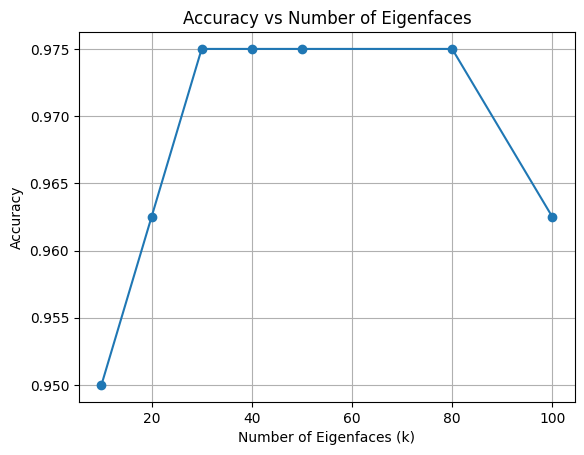

In [29]:
import matplotlib.pyplot as plt

plt.plot(k_values, accuracies, marker='o')
plt.xlabel("Number of Eigenfaces (k)")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Number of Eigenfaces")
plt.grid()
plt.show()